# Data set 01 tabla 2


* **Analsis de Tabla dos uso de la ia por edad y sexo**

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Lectura de Data_set_01 - hoja Table 2
raw = pd.read_excel('Data/Data_set_01.xlsx', sheet_name='Table 2', header=None)
encabezados = raw.iloc[4, 1:20].tolist()

trad_cols = {
    'TOTAL': 'Total',
    '18-29': '18-29 anos',
    '30-44': '30-44 anos',
    '45-59': '45-59 anos',
    '60+': '60+ anos',
    'Male': 'Hombre',
    'Female': 'Mujer',
    'No HS diploma': 'Sin diploma de secundaria',
    'HS grad or equivalent': 'Secundaria completa o equivalente',
    'Some college/AA': 'Algo de universidad/tecnico',
    'BA+': 'Licenciatura o mas',
    'White, NH': 'Blanco no hispano',
    'Black, NH': 'Negro no hispano',
    'Hispanic': 'Hispano',
    'Other/2+, NH': 'Otro/2+ no hispano',
    '<$30k': 'Menos de $30k',
    '$30k-$60k': '$30k a $60k',
    '$60k-$100k': '$60k a $100k',
    '$100k+': '$100k o mas',
}

cols_finales = ['Categoria'] + [trad_cols.get(c, c) for c in encabezados]
df = raw.iloc[6:, 0:20].copy().reset_index(drop=True)
df.columns = cols_finales

trad_filas = {
    'Total Respondents': 'Total de encuestados',
    'Daily (NET)': 'Uso diario (NET)',
    'Multiple times daily': 'Varias veces al dia',
    'Daily': 'Una vez al dia',
    'A Few Times A Week/Month (NET)': 'Varias veces por semana/mes (NET)',
    'A few times a week': 'Varias veces por semana',
    'A few times a month': 'Varias veces por mes',
    'Rarely Or Never (NET)': 'Rara vez o nunca (NET)',
    'Rarely': 'Rara vez',
    'Never': 'Nunca',
    "Don't know": 'No sabe',
    'Skipped on web': 'Omitido en web',
    'Refused': 'Rechazo responder',
}

df['Categoria'] = df['Categoria'].astype(str).str.strip().replace(trad_filas)
df = df[df['Categoria'].notna() & (df['Categoria'].astype(str).str.strip() != '')].reset_index(drop=True)

# Guardar tabla ordenada en espanol
df.to_csv('Data/tabla2_ordenada_es.csv', index=False, encoding='utf-8-sig')

print('DataFrame listo:', df.shape)
print(df.to_string(index=False))

# Mostrar explicitamente las 4 categorias solicitadas
categorias_objetivo = ['Rara vez', 'Nunca', 'No sabe', 'Omitido en web']
print('\nCategorias solicitadas:')
print(df[df['Categoria'].isin(categorias_objetivo)].to_string(index=False))

DataFrame listo: (13, 20)
                        Categoria Total 18-29 anos 30-44 anos 45-59 anos 60+ anos Hombre Mujer Sin diploma de secundaria Secundaria completa o equivalente Algo de universidad/tecnico Licenciatura o mas Blanco no hispano Negro no hispano Hispano Otro/2+ no hispano Menos de $30k $30k a $60k $60k a $100k $100k o mas
             Total de encuestados  1163        231        298        271      363    566   597                       102                               332                         303                426               696              140     214                112           262         263          262         376
                 Uso diario (NET)   16%        17%        18%        16%      13%    19%   12%                        8%                                8%                         21%                20%               14%              18%     12%                30%           12%         12%          15%         21%
              Varias veces al

Grafico guardado en Data/grafico_barras_tabla2_total.png


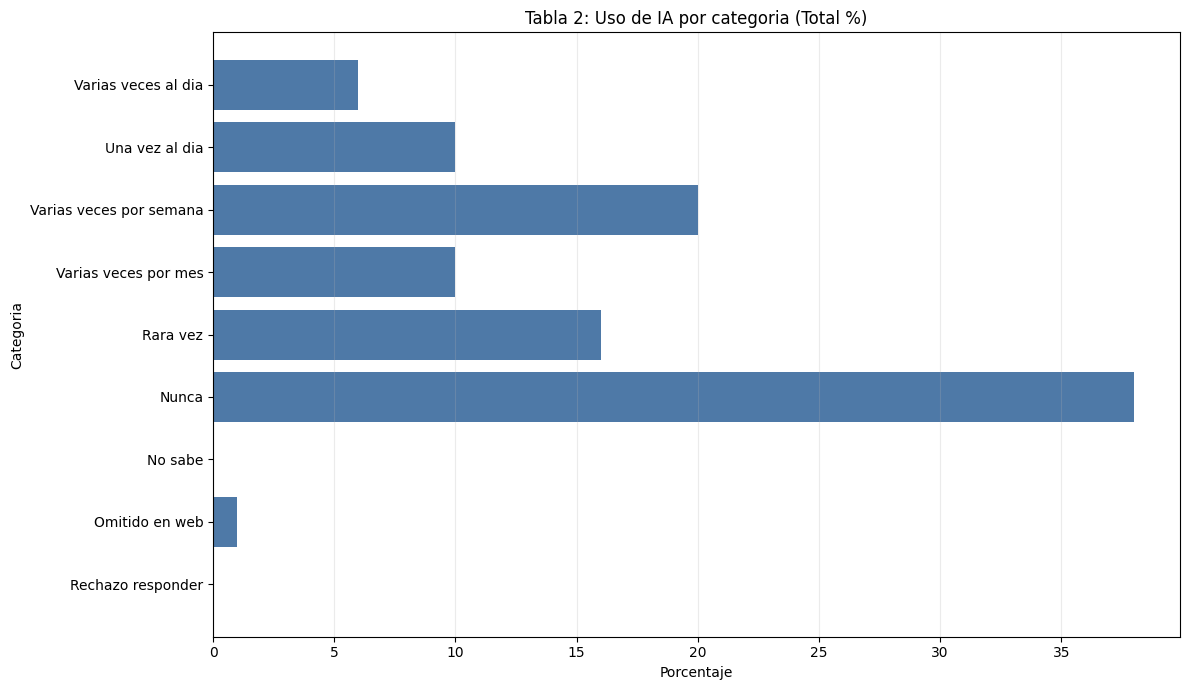

In [19]:
# Grafico de barras con las filas del Excel (Tabla 2, columna Total)
datos_barras = df.copy()

# Evitar mezclar conteos absolutos con porcentajes
datos_barras = datos_barras[datos_barras['Categoria'] != 'Total de encuestados'].copy()

# Excluir categorias agregadas (NET) para evitar duplicados por suma
datos_barras = datos_barras[~datos_barras['Categoria'].str.contains(r'\(NET\)', case=False, na=False)].copy()

# Convertir la columna Total (porcentajes) a numerico
datos_barras['Total_%'] = (
    datos_barras['Total']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.replace('-', '0', regex=False)
    .str.strip()
    .replace('', '0')
    .astype(float)
)

plt.figure(figsize=(12, 7))
plt.barh(datos_barras['Categoria'], datos_barras['Total_%'], color='#4e79a7')
plt.title('Tabla 2: Uso de IA por categoria (Total %)')
plt.xlabel('Porcentaje')
plt.ylabel('Categoria')
plt.grid(axis='x', alpha=0.25)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('Data/grafico_barras_tabla2_total.png', dpi=300, bbox_inches='tight')
print('Grafico guardado en Data/grafico_barras_tabla2_total.png')
plt.show()

Grafico guardado en Data/graficos_tabla2_edad_sexo.png


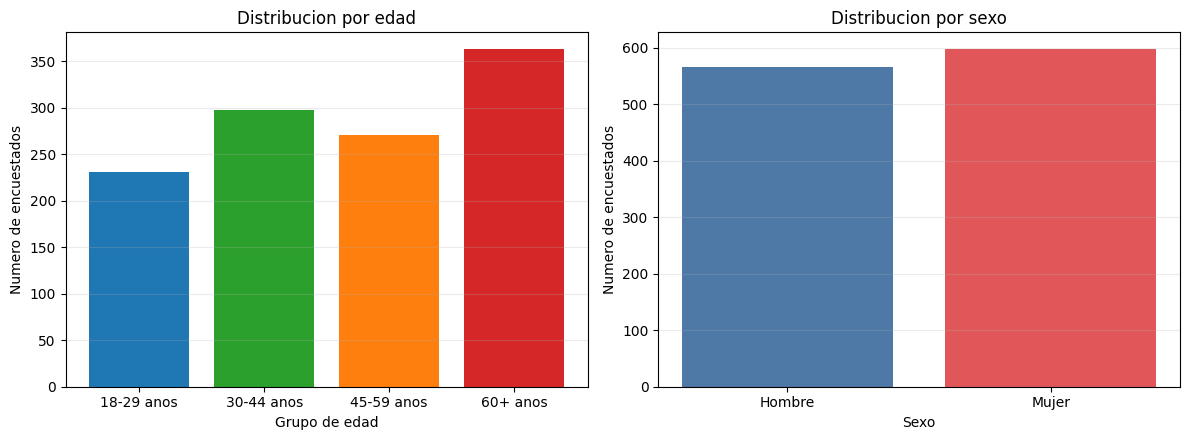

In [20]:
# Solo 2 graficos: edad y sexo (en el mismo cuadernillo)
fila_total = df[df['Categoria'] == 'Total de encuestados']
if fila_total.empty:
    raise ValueError('No se encontro la fila "Total de encuestados".')

edad = fila_total[['18-29 anos', '30-44 anos', '45-59 anos', '60+ anos']].iloc[0].astype(float)
sexo = fila_total[['Hombre', 'Mujer']].iloc[0].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(edad.index, edad.values, color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'])
axes[0].set_title('Distribucion por edad')
axes[0].set_xlabel('Grupo de edad')
axes[0].set_ylabel('Numero de encuestados')
axes[0].grid(axis='y', alpha=0.25)

axes[1].bar(sexo.index, sexo.values, color=['#4e79a7', '#e15759'])
axes[1].set_title('Distribucion por sexo')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Numero de encuestados')
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
fig.savefig('Data/graficos_tabla2_edad_sexo.png', dpi=300, bbox_inches='tight')
print('Grafico guardado en Data/graficos_tabla2_edad_sexo.png')
plt.show()

## Interpretacion de los datos


**Distribución por Edad**
* **60+ años:** 31.2% 
* **30-44 años:** 25.6%
* **45-59 años:** 23.3%
* **18-29 años:** 19.9%

**Distribución por Sexo**
* **Mujer:** 51.3%
* **Hombre:** 48.7%



### Dependencia y Riesgo de IA

* **Tendencias de Uso:** El uso diario de herramientas de IA es significativamente mayor en los grupos más jóvenes y en los hombres.
* **Brecha de Adopción:** En el grupo de 60+ años, el **67%** reporta usar IA "Rara vez o nunca", evidenciando una clara brecha tecnológica.






# Data set 01 tabla 3


* **Analsis de Tabla dos uso de la ia por edad y sexo**

DataFrame de Tabla 3 (ordenado):
                           Categoria Total 18-29 anos 30-44 anos 45-59 anos 60+ anos Hombre Mujer Sin diploma de secundaria Secundaria completa o equivalente Algo de universidad/tecnico Licenciatura o mas Blanco no hispano Negro no hispano Hispano Otro/2+ no hispano Menos de $30k $30k a $60k $60k a $100k $100k o mas
                        Aumento leve   25%        31%        32%        22%      18%    29%   22%                       22%                               18%                         26%                31%               25%              26%     21%                33%           21%         25%          22%         31%
               Aumento significativo   15%        13%        18%        17%      12%    15%   15%                        3%                                9%                         13%                24%               13%              20%     12%                24%           11%         13%          14%         20%
    Aumento s

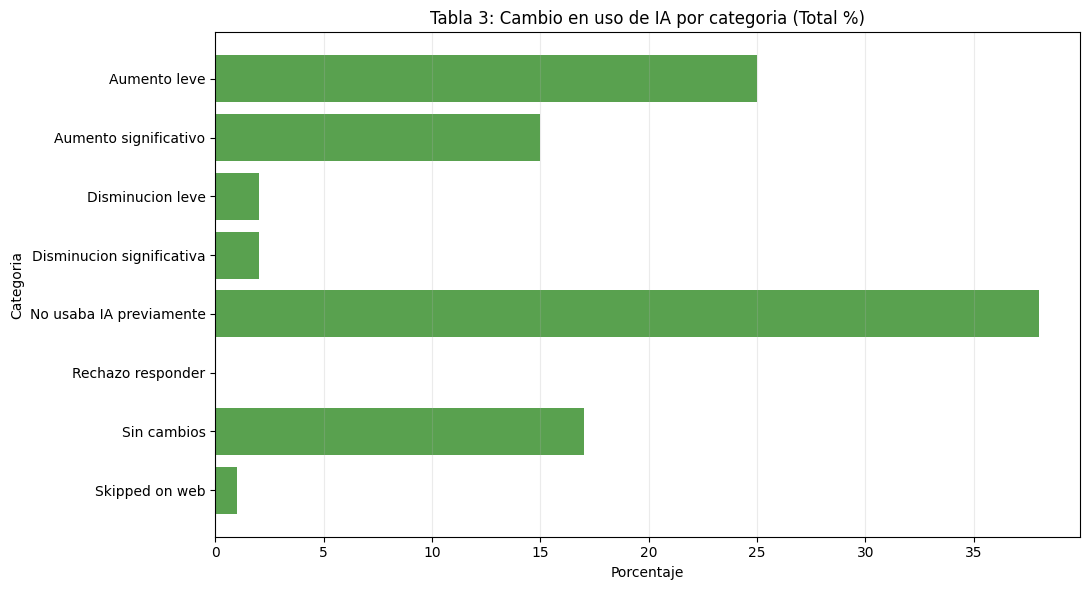

In [22]:
# Grafico de barras con las filas del Excel (Tabla 3, columna Total)
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar que exista df_tabla3_ordenada aunque se ejecute esta celda sola
if 'df_tabla3_ordenada' not in globals():
    try:
        df_tabla3_ordenada = pd.read_csv('Data/tabla3_ordenada_es.csv')
    except FileNotFoundError:
        raw_t3 = pd.read_excel('Data/Data_set_01.xlsx', sheet_name='Table 3', header=None)
        encabezados_t3 = raw_t3.iloc[4, 1:20].tolist()
        trad_cols_t3 = {
            'TOTAL': 'Total',
            '18-29': '18-29 anos',
            '30-44': '30-44 anos',
            '45-59': '45-59 anos',
            '60+': '60+ anos',
            'Male': 'Hombre',
            'Female': 'Mujer',
            'No HS diploma': 'Sin diploma de secundaria',
            'HS grad or equivalent': 'Secundaria completa o equivalente',
            'Some college/AA': 'Algo de universidad/tecnico',
            'BA+': 'Licenciatura o mas',
            'White, NH': 'Blanco no hispano',
            'Black, NH': 'Negro no hispano',
            'Hispanic': 'Hispano',
            'Other/2+, NH': 'Otro/2+ no hispano',
            '<$30k': 'Menos de $30k',
            '$30k-$60k': '$30k a $60k',
            '$60k-$100k': '$60k a $100k',
            '$100k+': '$100k o mas',
        }
        trad_filas_t3 = {
            'Total Respondents': 'Total de encuestados',
            'Significantly/Slightly Increased (NET)': 'Aumento significativo/leve (NET)',
            'Significantly increased': 'Aumento significativo',
            'Slightly increased': 'Aumento leve',
            'No change': 'Sin cambios',
            'Significantly/Slightly Decreased (NET)': 'Disminucion significativa/leve (NET)',
            'Slightly decreased': 'Disminucion leve',
            'Significantly decreased': 'Disminucion significativa',
            'I did not use AI previously': 'No usaba IA previamente',
            "Don't know": 'No sabe',
            'Refused': 'Rechazo responder',
            'Skipped on web': 'Omitido en web',
        }
        cols_t3_es = ['Categoria'] + [trad_cols_t3.get(c, c) for c in encabezados_t3]
        df_tabla3 = raw_t3.iloc[6:, 0:20].copy().reset_index(drop=True)
        df_tabla3.columns = cols_t3_es
        df_tabla3['Categoria'] = df_tabla3['Categoria'].astype(str).str.strip().replace(trad_filas_t3)
        df_tabla3 = df_tabla3[df_tabla3['Categoria'].notna() & (df_tabla3['Categoria'] != '')]
        df_tabla3_ordenada = df_tabla3.sort_values(by='Categoria', kind='stable').reset_index(drop=True)

print('DataFrame de Tabla 3 (ordenado):')
print(df_tabla3_ordenada.to_string(index=False))

datos_barras_t3 = df_tabla3_ordenada.copy()
datos_barras_t3 = datos_barras_t3[datos_barras_t3['Categoria'] != 'Total de encuestados'].copy()

# Excluir categorias agregadas (NET) para evitar duplicados por suma
datos_barras_t3 = datos_barras_t3[~datos_barras_t3['Categoria'].str.contains(r'\(NET\)', case=False, na=False)].copy()

datos_barras_t3['Total_%'] = (
    datos_barras_t3['Total']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.replace('-', '', regex=False)
    .str.strip()
    .replace('', pd.NA)
    .astype(float)
)

datos_barras_t3 = datos_barras_t3.dropna(subset=['Total_%'])

plt.figure(figsize=(11, 6))
plt.barh(datos_barras_t3['Categoria'], datos_barras_t3['Total_%'], color='#59a14f')
plt.title('Tabla 3: Cambio en uso de IA por categoria (Total %)')
plt.xlabel('Porcentaje')
plt.ylabel('Categoria')
plt.grid(axis='x', alpha=0.25)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('Data/grafico_barras_tabla3_total.png', dpi=300, bbox_inches='tight')
print('Grafico guardado en Data/grafico_barras_tabla3_total.png')
plt.show()

Grafico guardado en Data/graficos_tabla3_edad_sexo.png


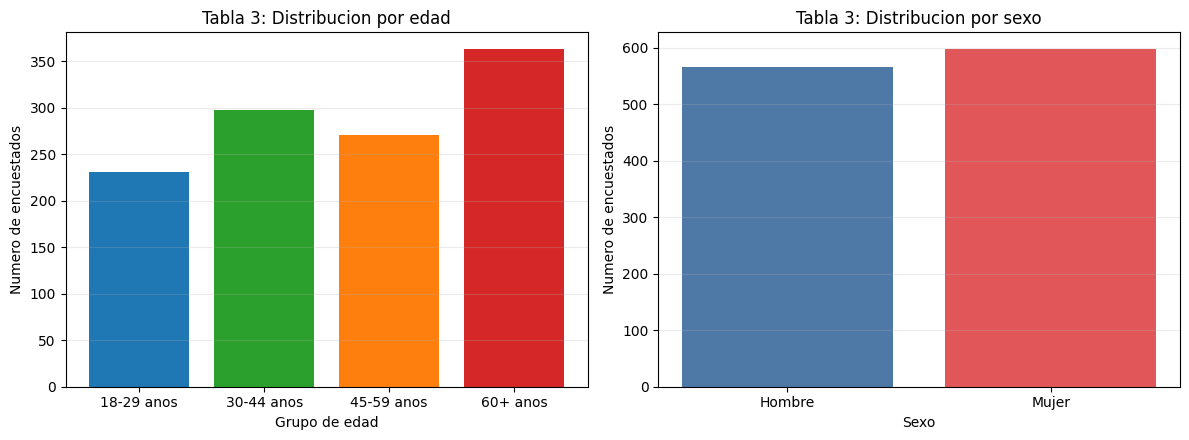

In [24]:
# Histogramas por edad y sexo (Tabla 3)
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar que exista df_tabla3_ordenada aunque se ejecute esta celda sola
if 'df_tabla3_ordenada' not in globals():
    try:
        df_tabla3_ordenada = pd.read_csv('Data/tabla3_ordenada_es.csv')
    except FileNotFoundError:
        raise ValueError('Primero ejecuta la celda de construccion de Tabla 3 o genera Data/tabla3_ordenada_es.csv')

fila_total_t3 = df_tabla3_ordenada[df_tabla3_ordenada['Categoria'] == 'Total de encuestados']
if fila_total_t3.empty:
    raise ValueError('No se encontro la fila "Total de encuestados" en Tabla 3.')

edad_t3 = fila_total_t3[['18-29 anos', '30-44 anos', '45-59 anos', '60+ anos']].iloc[0].astype(float)
sexo_t3 = fila_total_t3[['Hombre', 'Mujer']].iloc[0].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(edad_t3.index, edad_t3.values, color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'])
axes[0].set_title('Tabla 3: Distribucion por edad')
axes[0].set_xlabel('Grupo de edad')
axes[0].set_ylabel('Numero de encuestados')
axes[0].grid(axis='y', alpha=0.25)

axes[1].bar(sexo_t3.index, sexo_t3.values, color=['#4e79a7', '#e15759'])
axes[1].set_title('Tabla 3: Distribucion por sexo')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Numero de encuestados')
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
fig.savefig('Data/graficos_tabla3_edad_sexo.png', dpi=300, bbox_inches='tight')
print('Grafico guardado en Data/graficos_tabla3_edad_sexo.png')
plt.show()

Aumento por nivel educativo (Tabla 3):
            Categoria                   Nivel educativo  Porcentaje
         Aumento leve         Sin diploma de secundaria        22.0
Aumento significativo         Sin diploma de secundaria         3.0
         Aumento leve Secundaria completa o equivalente        18.0
Aumento significativo Secundaria completa o equivalente         9.0
         Aumento leve       Algo de universidad/tecnico        26.0
Aumento significativo       Algo de universidad/tecnico        13.0
         Aumento leve                Licenciatura o mas        31.0
Aumento significativo                Licenciatura o mas        24.0
Grafico guardado en Data/grafico_tabla3_aumento_nivel_educativo.png


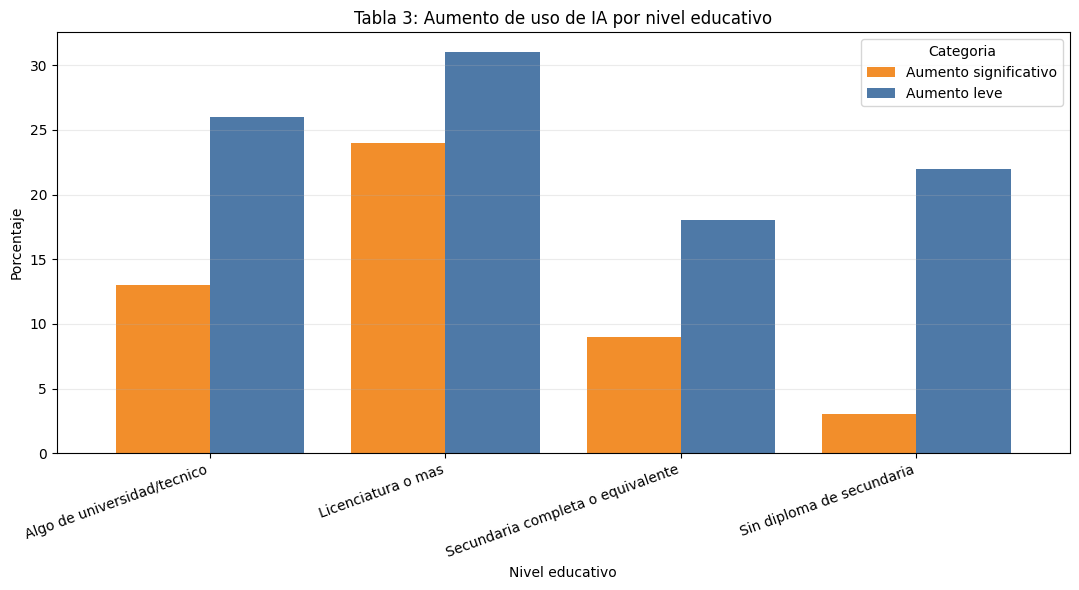

In [25]:
# Por nivel educativo: que tanto aumento (Tabla 3)
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar que exista df_tabla3_ordenada
if 'df_tabla3_ordenada' not in globals():
    df_tabla3_ordenada = pd.read_csv('Data/tabla3_ordenada_es.csv')

niveles_educativos = [
    'Sin diploma de secundaria',
    'Secundaria completa o equivalente',
    'Algo de universidad/tecnico',
    'Licenciatura o mas',
]

# Excluir fila NET para graficar solo categorias base
filas_objetivo = [
    'Aumento significativo',
    'Aumento leve',
]

base = df_tabla3_ordenada[df_tabla3_ordenada['Categoria'].isin(filas_objetivo)].copy()
if base.empty:
    raise ValueError('No se encontraron las filas de aumento en Tabla 3.')

# Convertir porcentajes a numerico
for col in niveles_educativos:
    base[col] = (
        base[col]
        .astype(str)
        .str.replace('%', '', regex=False)
        .str.replace('-', '0', regex=False)
        .str.strip()
        .replace('', '0')
        .astype(float)
    )

# Formato largo para imprimir y graficar
aumento_edu = base.melt(
    id_vars='Categoria',
    value_vars=niveles_educativos,
    var_name='Nivel educativo',
    value_name='Porcentaje',
)

print('Aumento por nivel educativo (Tabla 3):')
print(aumento_edu.to_string(index=False))

# Grafico de barras agrupadas
pivot = aumento_edu.pivot(index='Nivel educativo', columns='Categoria', values='Porcentaje')
pivot = pivot[[c for c in filas_objetivo if c in pivot.columns]]

ax = pivot.plot(kind='bar', figsize=(11, 6), width=0.8, color=['#f28e2b', '#4e79a7'])
ax.set_title('Tabla 3: Aumento de uso de IA por nivel educativo')
ax.set_xlabel('Nivel educativo')
ax.set_ylabel('Porcentaje')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=20, ha='right')
plt.legend(title='Categoria')
plt.tight_layout()
plt.savefig('Data/grafico_tabla3_aumento_nivel_educativo.png', dpi=300, bbox_inches='tight')
print('Grafico guardado en Data/grafico_tabla3_aumento_nivel_educativo.png')
plt.show()